# Customer Behavior Analysis

## Exploratory Data Analysis

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/customer_shopping_behavior.csv')

In [3]:
df.head(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly


In [4]:
df.shape

(5050, 17)

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [6]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
count,5050.000000,5050.000000,5050,5050,5050,4494.000000,5050,4680,5050,5050,4449.000000,5050,5050,5050,4502.000000,5050,5050
unique,NaN,NaN,3,30,5,NaN,54,4,25,5,NaN,2,6,2,NaN,6,7
top,NaN,NaN,Male,Shirt,Clothing,NaN,New York,M,Black,Spring,NaN,No,Standard,No,NaN,Credit Card,Monthly
freq,NaN,NaN,3018,320,2130,NaN,337,1981,404,1280,NaN,3462,1213,2789,NaN,954,946
mean,2519.570891,44.150495,NaN,NaN,NaN,144.765236,NaN,NaN,NaN,NaN,3.668195,NaN,NaN,NaN,25.221901,NaN,NaN
std,1470.402964,15.282328,NaN,NaN,NaN,275.590101,NaN,NaN,NaN,NaN,0.865357,NaN,NaN,NaN,14.521635,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,10.120000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN
25%,1252.250000,31.000000,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,13.000000,NaN,NaN
50%,2499.500000,44.000000,NaN,NaN,NaN,65.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,25.000000,NaN,NaN
75%,3740.750000,57.000000,NaN,NaN,NaN,89.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,38.000000,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [8]:
for i in df.columns:
    if df[i].dtype=='O':
        print('#'*25, i, '#'*25)
        print(df[i].unique())
        print()

######################### Gender #########################
['Female' 'Male' 'Other']

######################### Item Purchased #########################
['T-shirt' 'Sunglasses' 'Shirt' 'Gloves' 'Jewelry' 'Shorts' 'Hat'
 'Handbag' 'Shoes' 'Coat' 'Laptop' 'Hoodie' 'Phone' 'Jacket' 'Pants'
 'Backpack' 'Socks' 'Jeans' 'Bag' 'Belt' 'Watch' 'Headphones' 'Blouse'
 'Sandals' 'Skirt' 'Sweater' 'Scarf' 'Sneakers' 'Boots' 'Dress']

######################### Category #########################
['Clothing' 'Accessories' 'Outerwear' 'Electronics' 'Footwear']

######################### Location #########################
['California' 'South Carolina' 'Montana' 'Illinois' 'Alabama' 'Wisconsin'
 'Tennessee' 'Florida' 'Kentucky' 'Phoenix' 'Pennsylvania' 'Los Angeles'
 'Vermont' 'North Dakota' 'Ohio' 'Colorado' 'Maine' 'Massachusetts'
 'Arkansas' 'New York' 'Indiana' 'Maryland' 'New Mexico' 'Michigan'
 'Connecticut' 'Louisiana' 'Minnesota' 'Oregon' 'Kansas' 'Houston'
 'South Dakota' 'New Jersey' 'New Hamp

In [9]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df.groupby('Category')['Item Purchased'].unique()

Category
Accessories               [Sunglasses, Gloves, Jewelry, Hat, Handbag, Phone, Backpack, Belt, Bag, Headphones, Scarf, Watch, Shirt, Shoes, Laptop]
Clothing       [T-shirt, Shirt, Shorts, Shoes, Hoodie, Phone, Pants, Socks, Jeans, Bag, Blouse, Skirt, Sweater, Watch, Laptop, Dress, Headphones]
Electronics                                                                                 [Laptop, Phone, Watch, Bag, Shoes, Shirt, Headphones]
Footwear                                                                                                        [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                                                                          [Coat, Jacket]
Name: Item Purchased, dtype: object

In [10]:
# Correct Mapping
correct_mapping = {
    # Clothing
    'T-shirt' : 'Clothing', 'Shirt' : 'Clothing', 'Shorts' : 'Clothing',
    'Hoodie' : 'Clothing', 'Pants' : 'Clothing', 'Socks' : 'Clothing',
    'Jeans' : 'Clothing', 'Blouse' : 'Clothing', 'Skirt' : 'Clothing',
    'Sweater' : 'Clothing', 'Dress' : 'Clothing',

    # Accessories
    'Sunglasses' : 'Accessories', 'Gloves' : 'Accessories', 
    'Jewelry' : 'Accessories', 'Hat' : 'Accessories',
    'Handbag' : 'Accessories', 'Backpack' : 'Accessories',
    'Belt' : 'Accessories', 'Scarf' : 'Accessories',
    'Bag' : 'Accessories',

    # Electronics
    'Laptop' : 'Electronics', 'Phone' : 'Electronics',
    'Headphones' : 'Electronics', 'Watch' : 'Electronics',

    # Footwear
    'Shoes' : 'Footwear', 'Sandals' : 'Footwear', 
    'Sneakers' : 'Footwear', 'Boots' : 'Footwear',

    # Outerwear
    'Coat' : 'Outerwear', 'Jacket' : 'Outerwear'
}

In [11]:
df['Category'] = df['Item Purchased'].map(correct_mapping)

In [12]:
df.groupby('Category')['Item Purchased'].unique()

Category
Accessories                 [Sunglasses, Gloves, Jewelry, Hat, Handbag, Backpack, Bag, Belt, Scarf]
Clothing       [T-shirt, Shirt, Shorts, Hoodie, Pants, Socks, Jeans, Blouse, Skirt, Sweater, Dress]
Electronics                                                      [Laptop, Phone, Watch, Headphones]
Footwear                                                          [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                            [Coat, Jacket]
Name: Item Purchased, dtype: object

In [13]:
null_val_df = pd.DataFrame(df.isnull().sum()[df.isnull().sum()>0], columns=['No_of_Null_Values'])
null_val_df

,No_of_Null_Values
Purchase Amount (USD),556
Size,370
Review Rating,601
Previous Purchases,548


### Treating Null Values

#### Size

In [14]:
df['Size'].unique()

array(['XL', 'M', 'L', 'S', nan], dtype=object)

In [15]:
df.groupby('Category')['Size'].unique()

Category
Accessories    [M, L, S, XL, nan]
Clothing       [XL, M, S, L, nan]
Electronics    [nan, L, S, M, XL]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [16]:
df.groupby('Category')['Item Purchased'].unique()

Category
Accessories                 [Sunglasses, Gloves, Jewelry, Hat, Handbag, Backpack, Bag, Belt, Scarf]
Clothing       [T-shirt, Shirt, Shorts, Hoodie, Pants, Socks, Jeans, Blouse, Skirt, Sweater, Dress]
Electronics                                                      [Laptop, Phone, Watch, Headphones]
Footwear                                                          [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                            [Coat, Jacket]
Name: Item Purchased, dtype: object

In [17]:
# Replacing values in size column in Accessories Category with "Free Size"
df.loc[df['Category']=='Accessories', 'Size']='Free Size'

In [18]:
# Replacing values in size column in Electronics Category with "Not Applicable"
df.loc[df['Category']=='Electronics', 'Size']='Not Applicable'

In [19]:
# Replacing values in size column in footwear category since footwear comes in numeric sizes.
df.loc[df['Category']=='Footwear', 'Size']='Not Available'

In [20]:
# Replacing values in size column in clothing category with mode of size of clothing category.
df.loc[(df['Category']=='Clothing') & (df['Size'].isnull()), 'Size'] = df[df['Category']=='Clothing']['Size'].mode()[0]

In [21]:
df.groupby('Category')['Size'].unique()

Category
Accessories         [Free Size]
Clothing          [XL, M, S, L]
Electronics    [Not Applicable]
Footwear        [Not Available]
Outerwear         [XL, L, S, M]
Name: Size, dtype: object

In [22]:
print(f'Number of columns containing null values : {len(df.isnull().sum()[df.isnull().sum()>0])}')
df.isnull().sum()[df.isnull().sum()>0]

Number of columns containing null values : 3


Purchase Amount (USD)    556
Review Rating            601
Previous Purchases       548
dtype: int64

#### Review Rating

In [23]:
print(f'Mean : {df['Review Rating'].mean()}')
print(f'Median : {df['Review Rating'].median()}')
print(f'Mode : {df['Review Rating'].mode()[0]}')

Mean : 3.668195100022477
Median : 3.7
Mode : 4.0


In [24]:
# Treating null values in Review Rating Column with the mean of respective ratings of items purchased.
df.groupby('Item Purchased')['Review Rating'].mean()

Item Purchased
Backpack      3.758333
Bag           3.168539
Belt          3.762963
Blouse        3.677647
Boots         3.813194
Coat          3.721875
Dress         3.750000
Gloves        3.862774
Handbag       3.771975
Hat           3.796753
Headphones    3.075949
Hoodie        3.716779
Jacket        3.761446
Jeans         3.651969
Jewelry       3.761850
Laptop        3.191176
Pants         3.720833
Phone         2.939024
Sandals       3.837037
Scarf         3.702564
Shirt         3.427273
Shoes         3.546154
Shorts        3.722981
Skirt         3.779747
Sneakers      3.757931
Socks         3.755063
Sunglasses    3.745679
Sweater       3.768712
T-shirt       3.790541
Watch         3.100000
Name: Review Rating, dtype: float64

In [25]:
df['Review Rating'] = df['Review Rating'].fillna(df.groupby('Item Purchased')['Review Rating'].transform('mean'))

In [26]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [27]:
df.head(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free Size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly


In [28]:
df['Review Rating'] = df['Review Rating'].round(2)

#### Previous Purchases

In [29]:
df['Previous Purchases'].fillna(0, inplace=True)

In [30]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases          0
Payment Method              0
Frequency of Purchases      0
dtype: int64

#### Purchase Amount (USD)

In [31]:
df.groupby('Item Purchased')['Purchase Amount (USD)'].mean()

Item Purchased
Backpack       60.111111
Bag           735.773625
Belt           59.993902
Blouse         60.802326
Boots          62.616438
Coat           57.851852
Dress          62.168675
Gloves         60.550000
Handbag        57.987261
Hat            60.787097
Headphones    831.344565
Hoodie         58.059603
Jacket         56.777108
Jeans          60.456693
Jewelry        59.011494
Laptop        805.502027
Pants          59.005848
Phone         734.477349
Sandals        57.527607
Scarf          61.157233
Shirt         279.935608
Shoes         276.343790
Shorts         60.073620
Skirt          59.723270
Sneakers       59.551724
Socks          58.188679
Sunglasses     59.975610
Sweater        57.638554
T-shirt        63.093333
Watch         685.231471
Name: Purchase Amount (USD), dtype: float64

In [32]:
# Replacing null values in purchase amount column with respective the mean of respective purchased item.
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df.groupby('Item Purchased')['Purchase Amount (USD)'].transform('mean'))

In [33]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

### Checking Duplicates

In [34]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
886,2834,43,Female,Jeans,Clothing,56.0,Arkansas,M,Teal,Fall,3.30,No,Free Shipping,No,19.0,Cash,Monthly
1402,1621,25,Male,Hat,Accessories,47.0,Virginia,Free Size,Charcoal,Winter,3.10,No,2-Day Shipping,Yes,27.0,PayPal,Every 3 Months
1509,974,60,Male,Jacket,Outerwear,75.0,Colorado,M,Teal,Fall,3.50,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly
1600,2135,55,Male,Sandals,Footwear,41.0,Virginia,Not Available,Maroon,Winter,2.90,No,Standard,No,35.0,Credit Card,Fortnightly
1665,1846,51,Male,Sandals,Footwear,78.0,Delaware,Not Available,Orange,Winter,2.80,No,2-Day Shipping,No,39.0,Bank Transfer,Quarterly
1797,3639,40,Female,Backpack,Accessories,20.0,Kansas,Free Size,Olive,Spring,4.60,No,Express,No,50.0,PayPal,Bi-Weekly
1870,3456,49,Female,T-shirt,Clothing,89.0,Ohio,M,Orange,Fall,4.70,No,Standard,No,13.0,Venmo,Annually
2033,1812,42,Male,Belt,Accessories,77.0,Wisconsin,Free Size,Blue,Summer,3.60,No,Standard,No,33.0,Bank Transfer,Annually
2113,3040,59,Female,Blouse,Clothing,48.0,Alabama,L,Blue,Spring,3.20,No,Next Day Air,No,31.0,PayPal,Bi-Weekly
2226,1371,27,Male,Scarf,Accessories,67.0,Montana,Free Size,Peach,Summer,3.70,No,2-Day Shipping,Yes,41.0,Bank Transfer,Every 3 Months


In [35]:
df[df['Customer ID']==974]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
483,974,60,Male,Jacket,Outerwear,75.0,Colorado,M,Teal,Fall,3.5,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly
1509,974,60,Male,Jacket,Outerwear,75.0,Colorado,M,Teal,Fall,3.5,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly


In [36]:
# Remove duplicate rows.
df = df.drop_duplicates(subset=['Customer ID'], keep='first')

In [37]:
len(df)

5000

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5000 non-null   int64  
 1   Age                     5000 non-null   int64  
 2   Gender                  5000 non-null   object 
 3   Item Purchased          5000 non-null   object 
 4   Category                5000 non-null   object 
 5   Purchase Amount (USD)   5000 non-null   float64
 6   Location                5000 non-null   object 
 7   Size                    5000 non-null   object 
 8   Color                   5000 non-null   object 
 9   Season                  5000 non-null   object 
 10  Review Rating           5000 non-null   float64
 11  Subscription Status     5000 non-null   object 
 12  Shipping Type           5000 non-null   object 
 13  Discount Applied        5000 non-null   object 
 14  Previous Purchases      5000 non-null   float

### Renaming the Headers

In [40]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.lower()

In [41]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [42]:
# Replacing purchase_amount_(usd) to purchase_amount
df = df.rename(columns={'purchase_amount_(usd)' : 'purchase_amount'})

In [43]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [44]:
# !pip install pyodbc sqlalchemy

In [45]:
# !python.exe -m pip install --upgrade pip

In [46]:
from sqlalchemy import create_engine
import urllib

In [47]:
# !pip install pymysql

In [48]:
username = 'root'
password = 'Kuldeep959'
host = 'localhost'
port = '3306'
database = 'data_analysis_project'

# Create connection engine
engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

In [49]:
table_name = 'customer_behavior_analysis'
df.to_sql(name=table_name, con=engine, if_exists='replace', index=False)

5000

In [50]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [51]:
df['category'].unique()

array(['Clothing', 'Accessories', 'Footwear', 'Outerwear', 'Electronics'],
      dtype=object)

In [52]:
df['previous_purchases'].describe()

count    5000.000000
mean       22.467800
std        15.801054
min         0.000000
25%         8.000000
50%        22.000000
75%        36.000000
max        50.000000
Name: previous_purchases, dtype: float64

<Axes: xlabel='previous_purchases'>

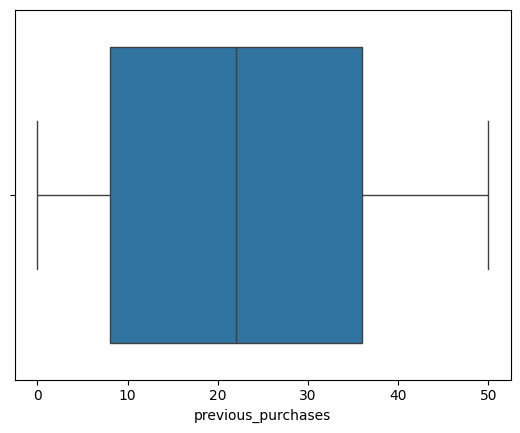

In [55]:
sns.boxplot(x='previous_purchases', data=df)